In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)

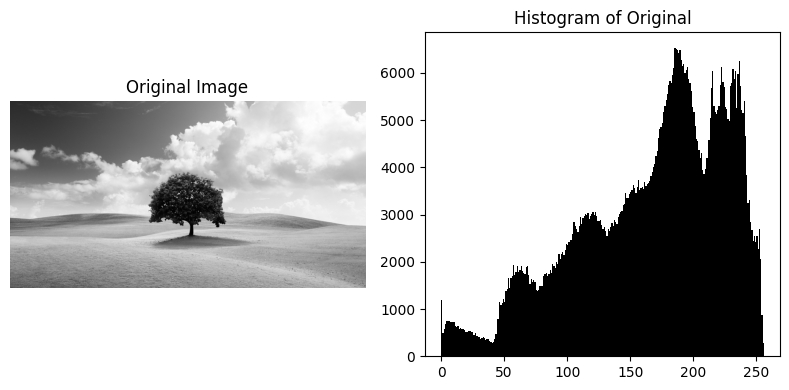

In [9]:
plt.figure(figsize=(8,4))


plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")


plt.subplot(1,2,2)
plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
plt.title("Histogram of Original")

plt.tight_layout()
plt.show()

In [10]:
def add_gaussian_noise(image, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

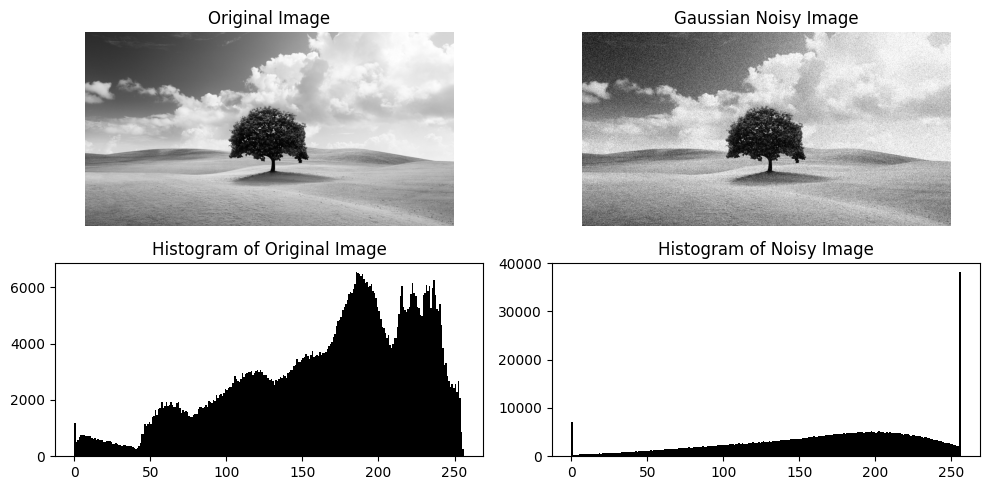

In [11]:
noisy_img = add_gaussian_noise(img)


plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Gaussian Noisy Image')
plt.axis('off')


plt.subplot(2, 2, 3)
plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Original Image')

plt.subplot(2, 2, 4)
plt.hist(noisy_img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Noisy Image')

plt.tight_layout()
plt.show()

In [12]:
def add_salt_pepper_noise(image, salt_prob=0.1, pepper_prob=0.1):
    noisy = np.copy(image)
    total_pixels = image.size


    num_salt = int(salt_prob * total_pixels)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255


    num_pepper = int(pepper_prob * total_pixels)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy



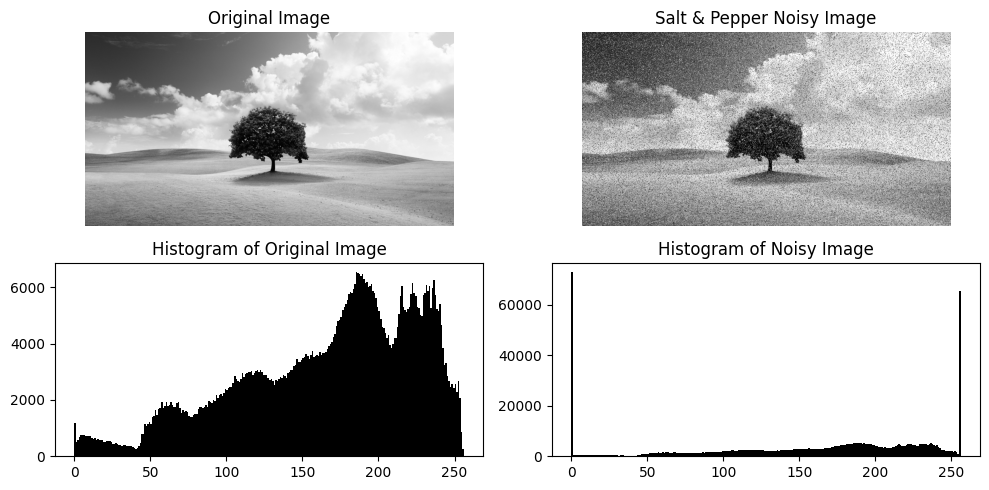

In [13]:
noisy_img = add_salt_pepper_noise(img)


plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Salt & Pepper Noisy Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Original Image')

plt.subplot(2, 2, 4)
plt.hist(noisy_img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Noisy Image')

plt.tight_layout()
plt.show()

In [14]:
def add_speckle_noise(image):
    row, col = image.shape
    gauss = np.random.normal(0, 0.2, (row, col))
    noisy = image.astype(np.float32) + image.astype(np.float32) * gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

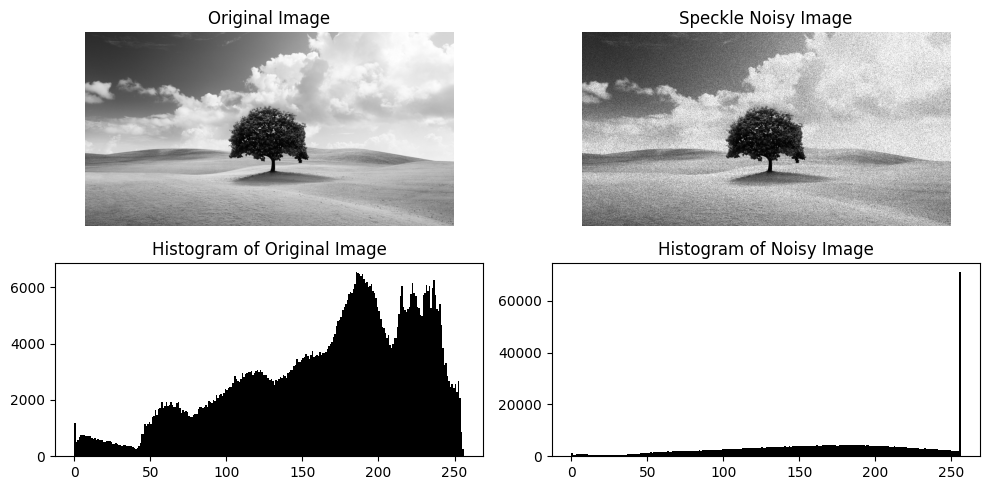

In [15]:
noisy_img = add_speckle_noise(img)


plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('Speckle Noisy Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Original Image')

plt.subplot(2, 2, 4)
plt.hist(noisy_img.ravel(), bins=256, range=[0,256], color='black')
plt.title('Histogram of Noisy Image')

plt.tight_layout()
plt.show()

In [16]:
def add_impulse_noise(image, noise_prob=0.01):
    row, col = image.shape
    noisy = np.array(image, dtype=np.uint8)
    mask = np.random.rand(row, col) < noise_prob
    noisy[mask] = np.random.randint(0, 256, np.count_nonzero(mask))
    return noisy

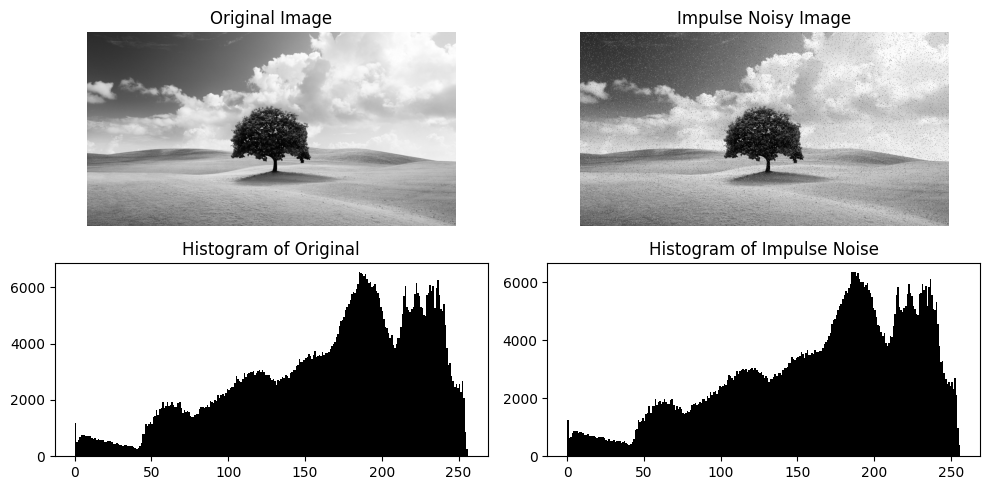

In [17]:
impulse_img = add_impulse_noise(img, noise_prob=0.05)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(impulse_img, cmap='gray')
plt.title("Impulse Noisy Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
plt.title("Histogram of Original")

plt.subplot(2,2,4)
plt.hist(impulse_img.ravel(), bins=256, range=[0,256], color='black')
plt.title("Histogram of Impulse Noise")

plt.tight_layout()
plt.show()

In [18]:
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt




path = kagglehub.dataset_download("paultimothymooney/sample-images-for-kaggle-demos")
print("Path to dataset files:", path)


image_files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
print("Found", len(image_files), "images")

100%|██████████| 1.07M/1.07M [00:00<00:00, 93.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/sample-images-for-kaggle-demos/versions/5
Found 8 images



Image 1/8: 1928768_1035869614877_9398_n.jpg


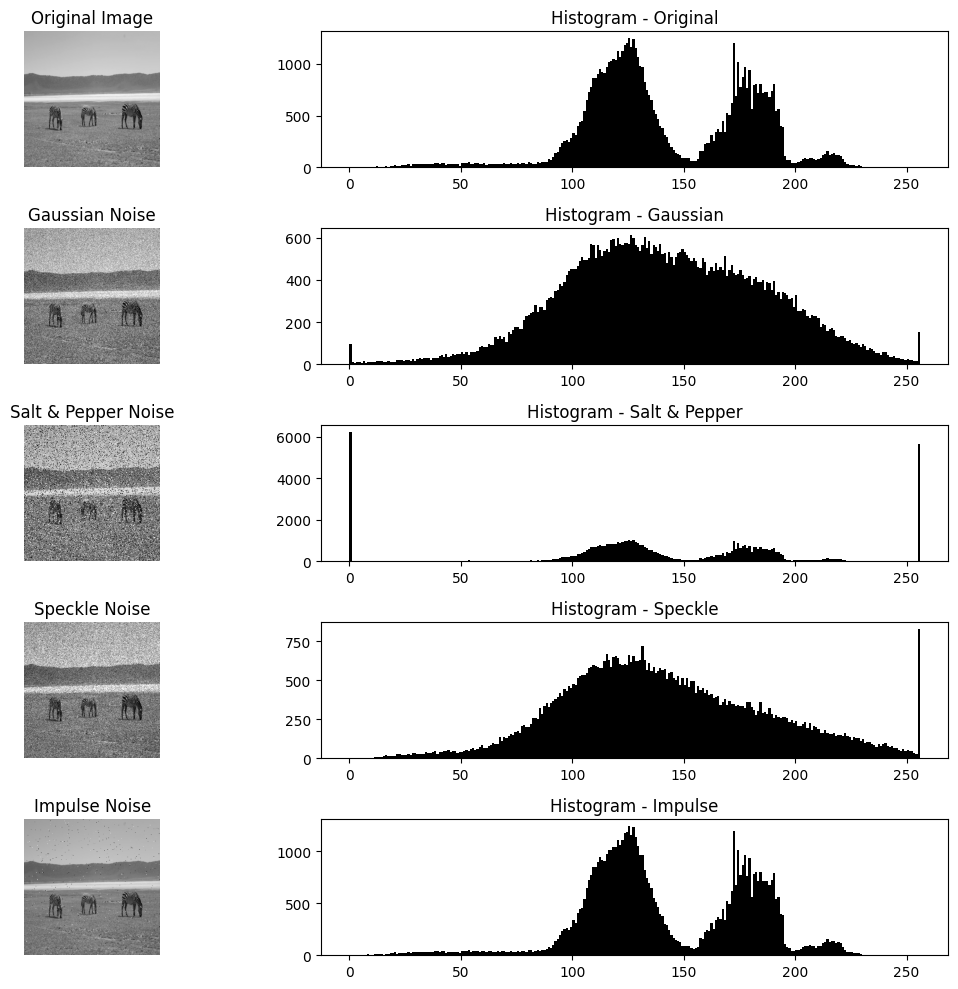


Image 2/8: 1928768_1037975147514_391_n.jpg


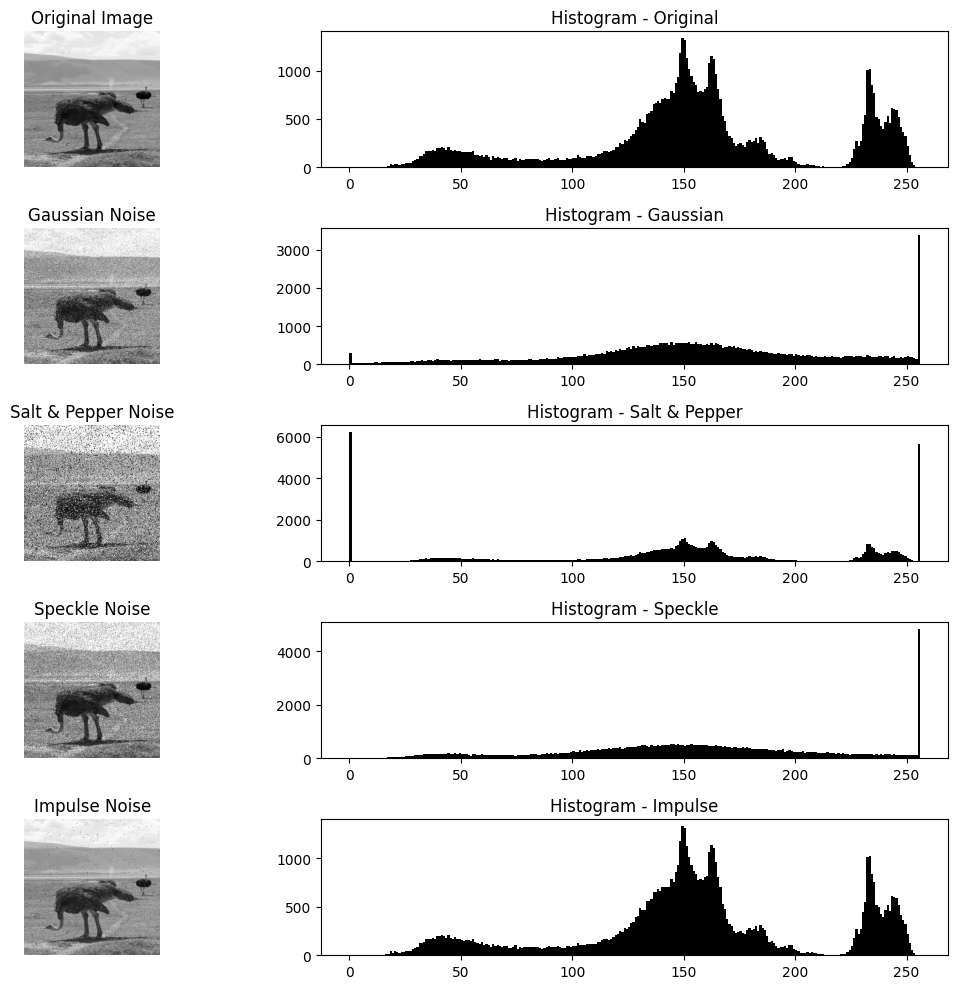


Image 3/8: 1928768_1035870414897_2872_n.jpg


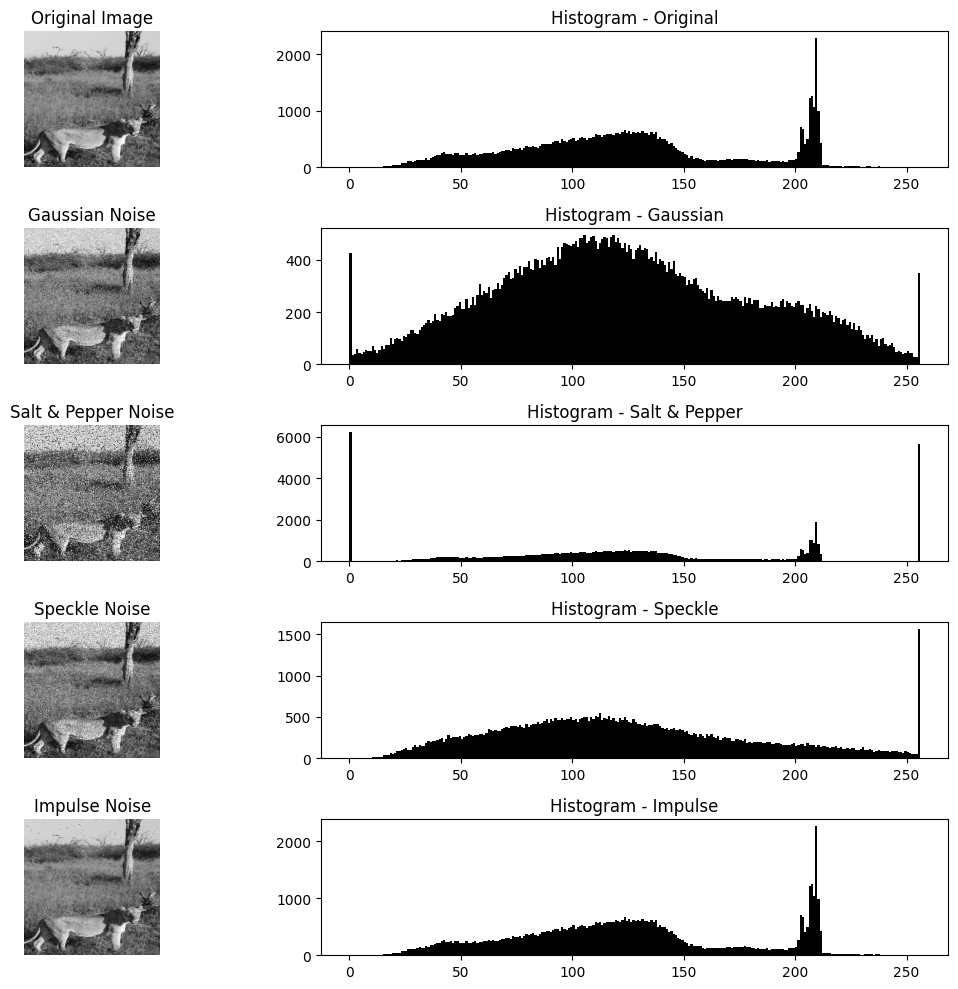


Image 4/8: 10348811_10203278436739581_4396533720123985351_o.jpg


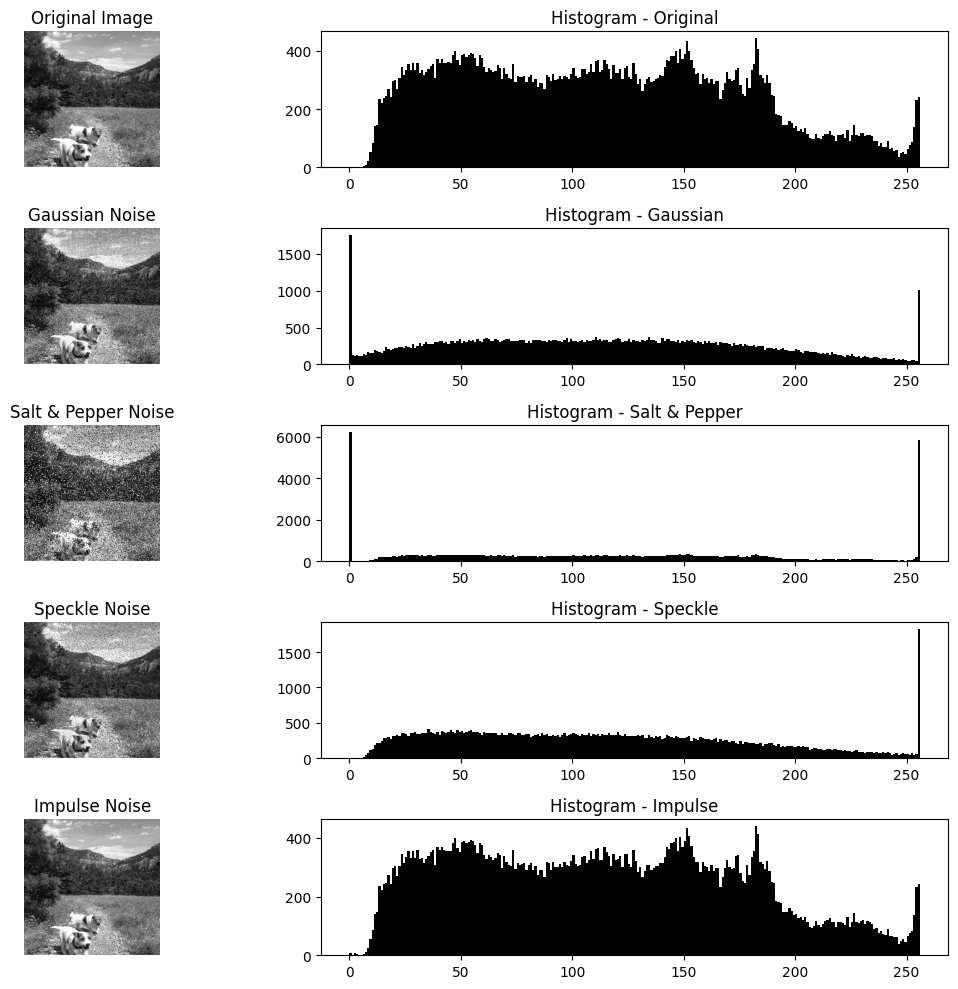


Image 5/8: 14068432_10208738211710543_3702836426568321706_o.jpg


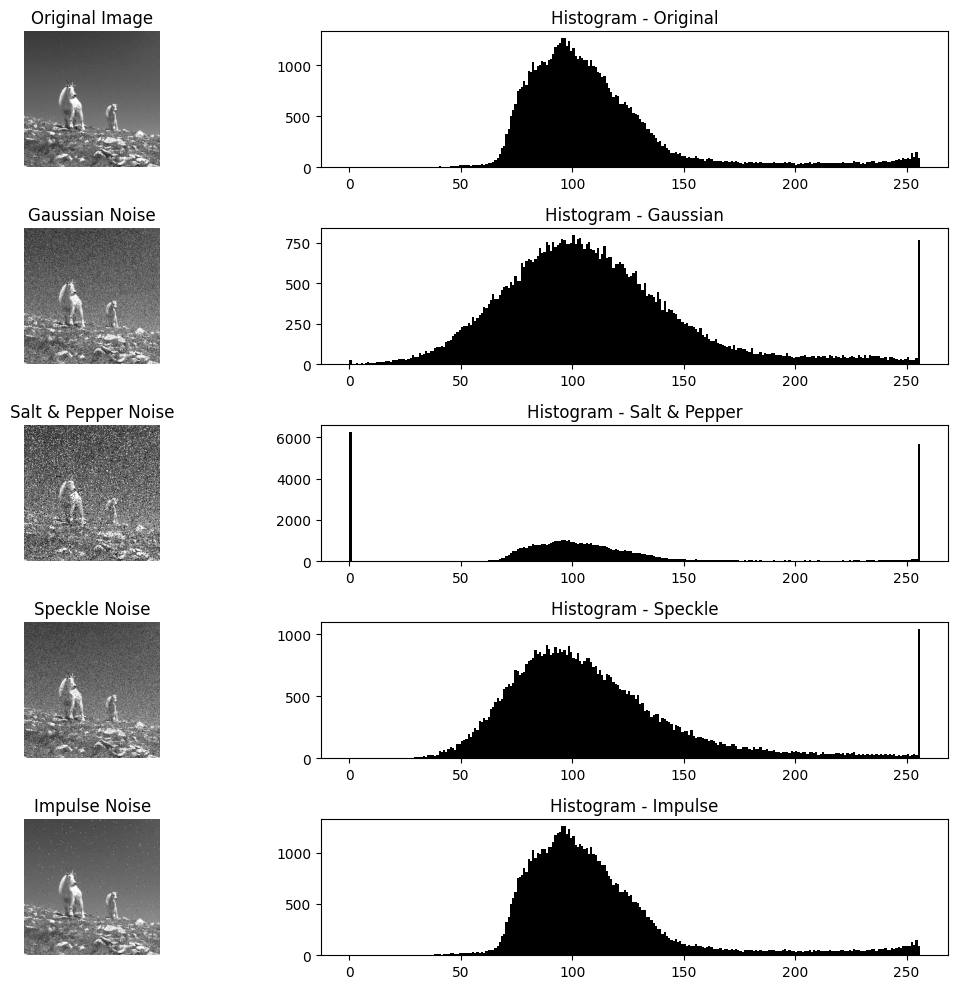


Image 6/8: 1928768_1037975187515_2166_n.jpg


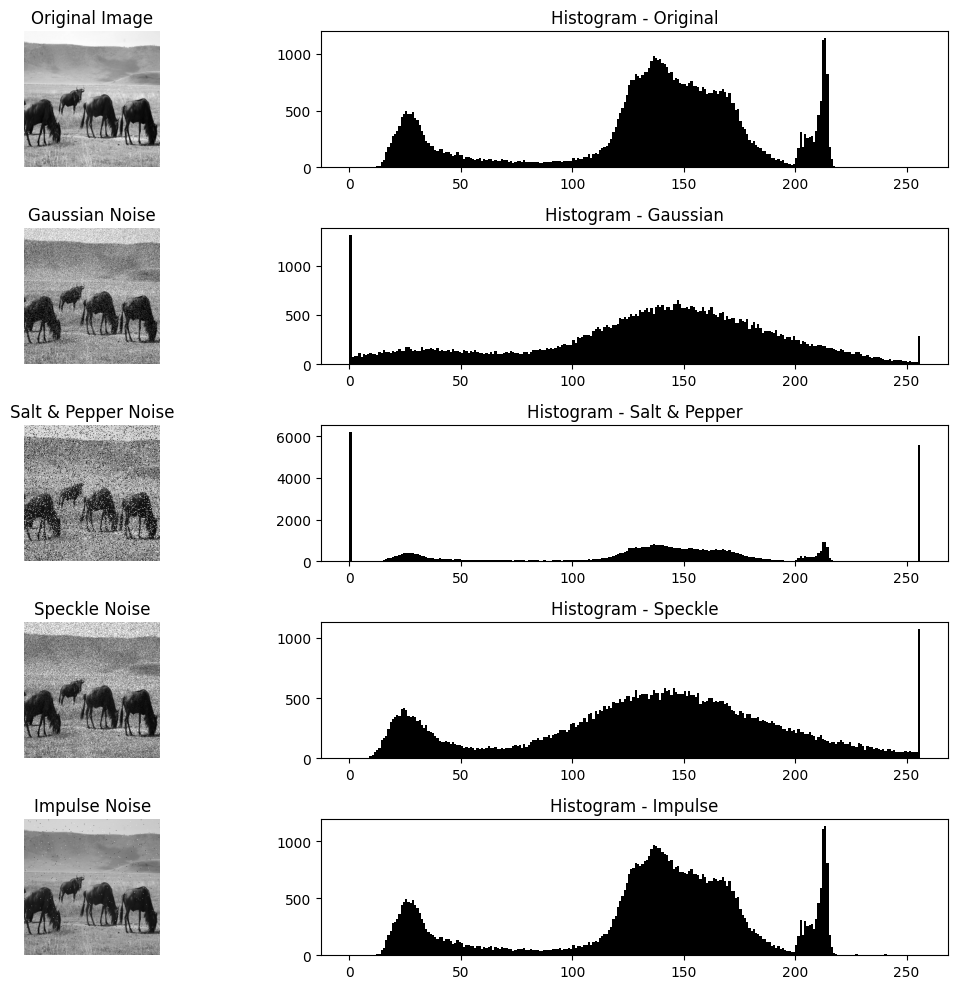


Image 7/8: 1928768_1035875455023_8071_n.jpg


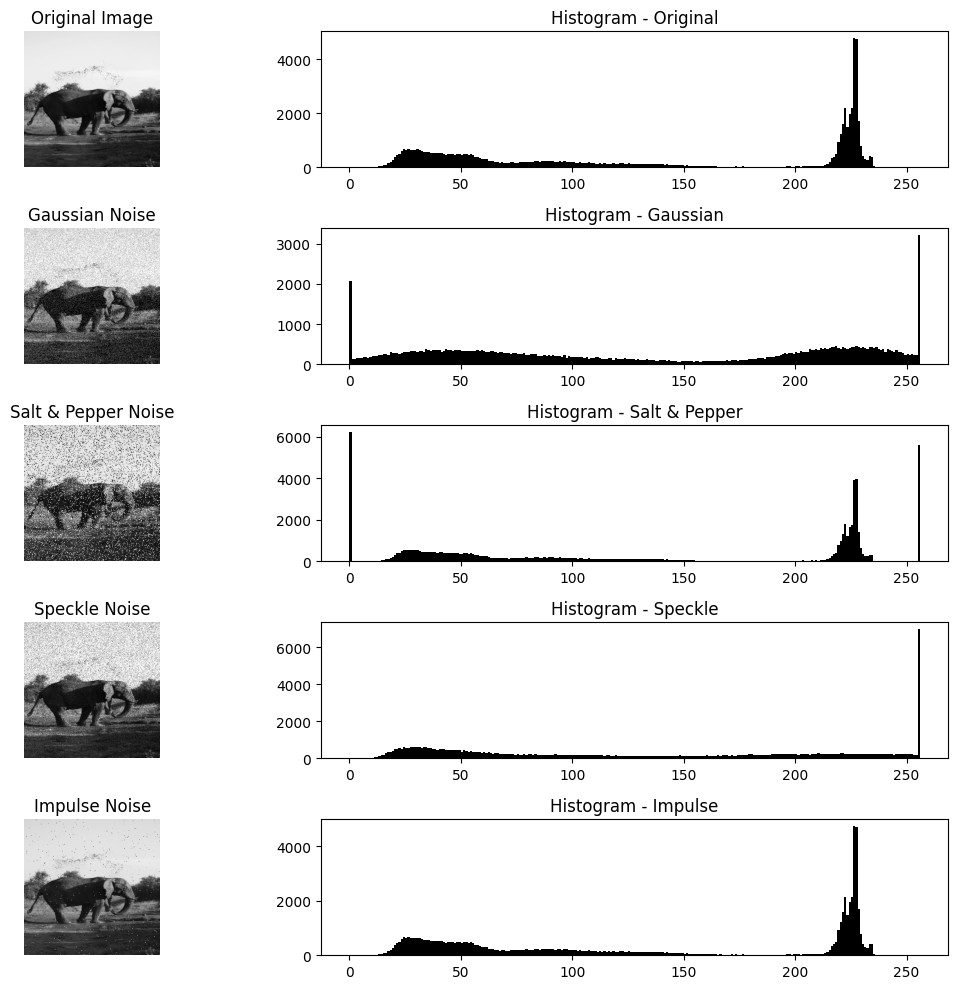


Image 8/8: 1928768_1037974227491_6531_n.jpg


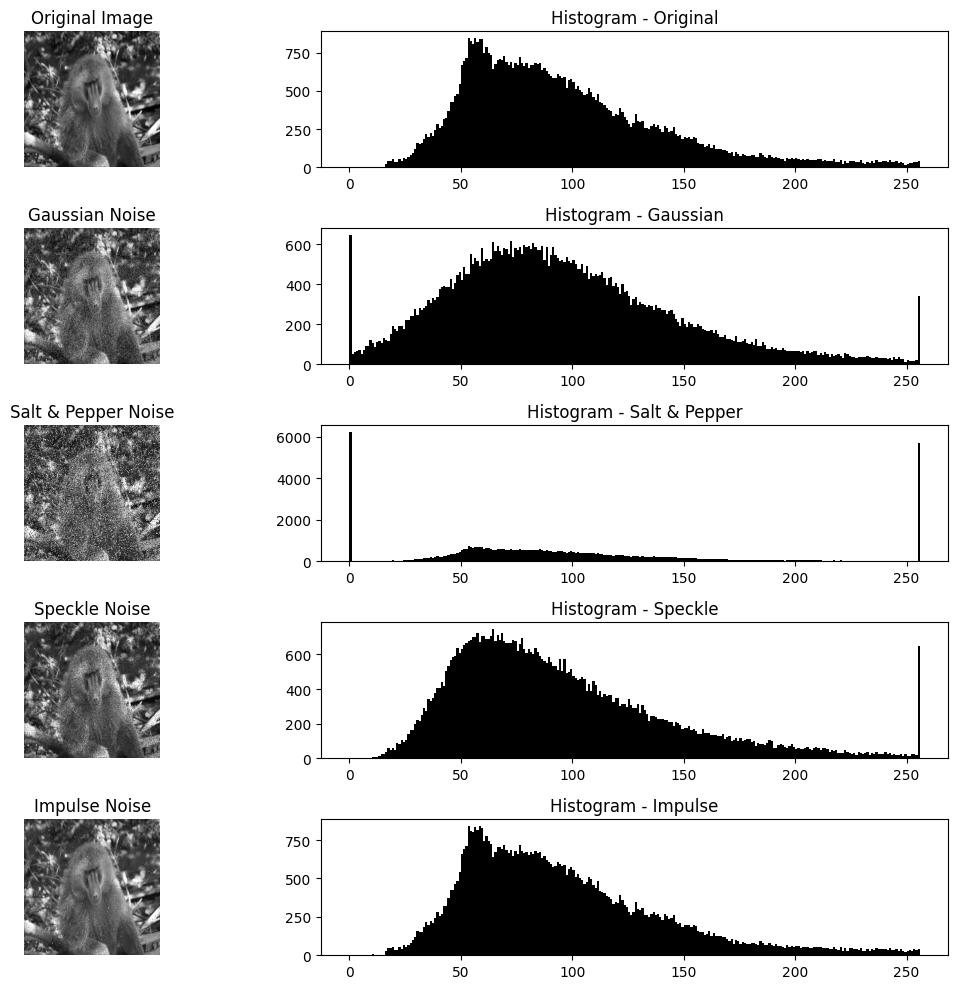

In [22]:
IMAGE_SIZE = (256, 256)
for i, file in enumerate(image_files):
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.resize(img, IMAGE_SIZE)

    print(f"\n======================")
    print(f"Image {i+1}/{len(image_files)}: {os.path.basename(file)}")
    print(f"======================")

    gaussian = add_gaussian_noise(img)
    sp = add_salt_pepper_noise(img)
    speckle = add_speckle_noise(img)
    impulse = add_impulse_noise(img)

    plt.figure(figsize=(12, 10))

    plt.subplot(5, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")
    plt.subplot(5, 2, 2)
    plt.hist(img.ravel(), bins=256, range=[0,256], color='black')
    plt.title("Histogram - Original")

    plt.subplot(5, 2, 3)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Gaussian Noise")
    plt.axis("off")
    plt.subplot(5, 2, 4)
    plt.hist(gaussian.ravel(), bins=256, range=[0,256], color='black')
    plt.title("Histogram - Gaussian")

    plt.subplot(5, 2, 5)
    plt.imshow(sp, cmap='gray')
    plt.title("Salt & Pepper Noise")
    plt.axis("off")
    plt.subplot(5, 2, 6)
    plt.hist(sp.ravel(), bins=256, range=[0,256], color='black')
    plt.title("Histogram - Salt & Pepper")

    plt.subplot(5, 2, 7)
    plt.imshow(speckle, cmap='gray')
    plt.title("Speckle Noise")
    plt.axis("off")
    plt.subplot(5, 2, 8)
    plt.hist(speckle.ravel(), bins=256, range=[0,256], color='black')
    plt.title("Histogram - Speckle")

    plt.subplot(5, 2, 9)
    plt.imshow(impulse, cmap='gray')
    plt.title("Impulse Noise")
    plt.axis("off")
    plt.subplot(5, 2, 10)
    plt.hist(impulse.ravel(), bins=256, range=[0,256], color='black')
    plt.title("Histogram - Impulse")

    plt.tight_layout()
    plt.show()